In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from vit_keras import vit

c:\Users\saidi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\saidi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encoun

# ==========================
# 1️⃣ Dataset Paths
# ==========================

In [ ]:
train_dir = "skin_dataset/train"
valid_dir = "skin_dataset/valid"
test_dir  = "skin_dataset/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


# ==========================
# 2️⃣ Data Preprocessing & Augmentation
# ==========================

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 686 images belonging to 3 classes.
Found 58 images belonging to 3 classes.
Found 28 images belonging to 3 classes.


# ==========================
# 3️⃣ Vision Transformer Model (from vit-keras)
# ==========================

In [ ]:
vit_model = vit.vit_b16(
    image_size=224,
    activation='softmax',
    pretrained=True,
    include_top=False,
    pretrained_top=False,
    classes=3
)

vit_model.trainable = False  # freeze pretrained layers

347502902/347502902 [==============================] - 105s 0us/step


c:\Users\saidi\AppData\Local\Programs\Python\Python311\Lib\site-packages\vit_keras\utils.py:81: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  warnings.warn(


# ==========================
# 4️⃣ Custom Top Layers
# ==========================

In [ ]:
model = models.Sequential([
    vit_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 classes: acne, dry, oil
])


In [13]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vit-b16 (Functional)        (None, 768)               85798656  
                                                                 
 flatten (Flatten)           (None, 768)               0         
                                                                 
 dense_2 (Dense)             (None, 256)               196864    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 3)                 771       
                                                                 
Total params: 85996291 (328.05 MB)
Trainable params: 197635 (772.01 KB)
Non-trainable params: 85798656 (327.30 MB)
_________________________________________________________________


# ==========================
# 5️⃣ Training
# ==========================

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10


22/22 [==============================] - 151s 6s/step - loss: 1.1832 - accuracy: 0.4519 - val_loss: 0.5715 - val_accuracy: 0.7759
Epoch 2/10
22/22 [==============================] - 130s 6s/step - loss: 0.6006 - accuracy: 0.7566 - val_loss: 0.3836 - val_accuracy: 0.8621
Epoch 3/10
22/22 [==============================] - 127s 6s/step - loss: 0.4387 - accuracy: 0.8236 - val_loss: 0.2999 - val_accuracy: 0.8966
Epoch 4/10
22/22 [==============================] - 130s 6s/step - loss: 0.3154 - accuracy: 0.8950 - val_loss: 0.2481 - val_accuracy: 0.9138
Epoch 5/10
22/22 [==============================] - 131s 6s/step - loss: 0.2921 - accuracy: 0.8965 - val_loss: 0.2195 - val_accuracy: 0.9310
Epoch 6/10
22/22 [==============================] - 131s 6s/step - loss: 0.2571 - accuracy: 0.9169 - val_loss: 0.2003 - val_accuracy: 0.9310
Epoch 7/10
22/22 [==============================] - 177s 8s/step - loss: 0.2247 - accuracy: 0.9257 - val_loss: 0.1729 - val_accuracy: 0.9483
Epoch 8/10


# ==========================
# 6️⃣ Evaluation
# ==========================

In [ ]:
loss, acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {acc:.4f}")

1/1 [==============================] - 4s 4s/step - loss: 0.1304 - accuracy: 0.9643

✅ Test Accuracy: 0.9643


In [16]:
#model.save("skin_classification_model.keras")

# ==========================
# 7️⃣ Visualization
# ==========================

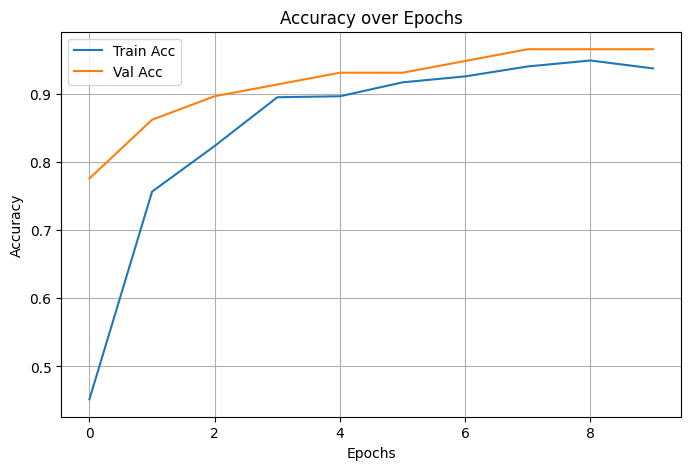

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

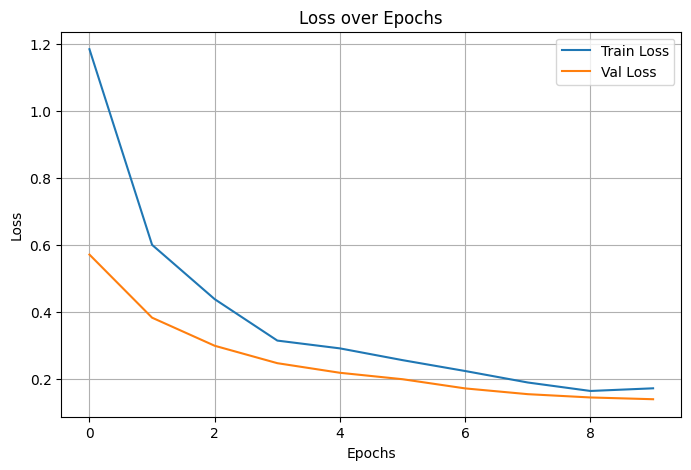

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# ==========================
# 8️⃣ Classification Report
# ==========================

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

1/1 [==============================] - 8s 8s/step

Classification Report:

              precision    recall  f1-score   support

        acne       1.00      1.00      1.00        10
         dry       1.00      0.89      0.94         9
         oil       0.90      1.00      0.95         9

    accuracy                           0.96        28
   macro avg       0.97      0.96      0.96        28
weighted avg       0.97      0.96      0.96        28



# ==========================
# 9️⃣ Confusion Matrix
# ==========================

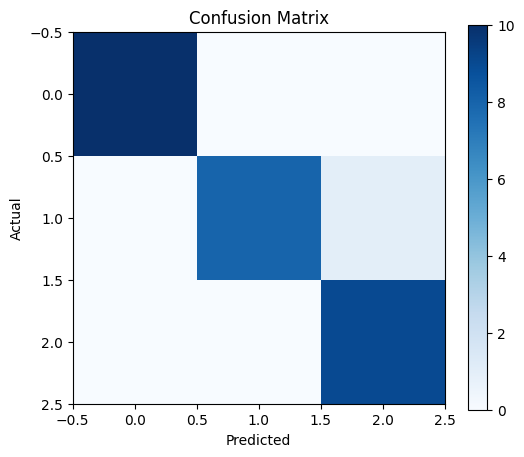

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# ==========================
# 🔟 Evaluation Graphs
# ==========================


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import seaborn as sns

class_names = list(test_gen.class_indices.keys())
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

# Predict probabilities
y_prob = model.predict(test_gen)

1/1 [==============================] - 15s 15s/step


# --------------------------
# (1) ROC Curves
# --------------------------

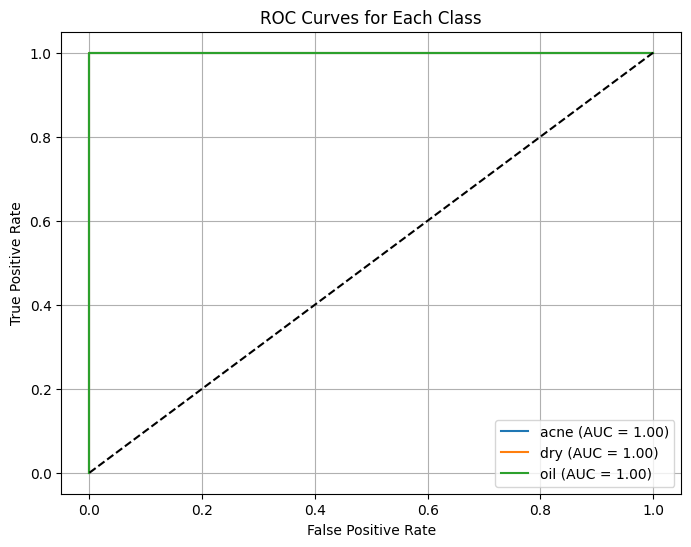

In [ ]:
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves for Each Class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# --------------------------
# (2) Precision-Recall Curves
# --------------------------

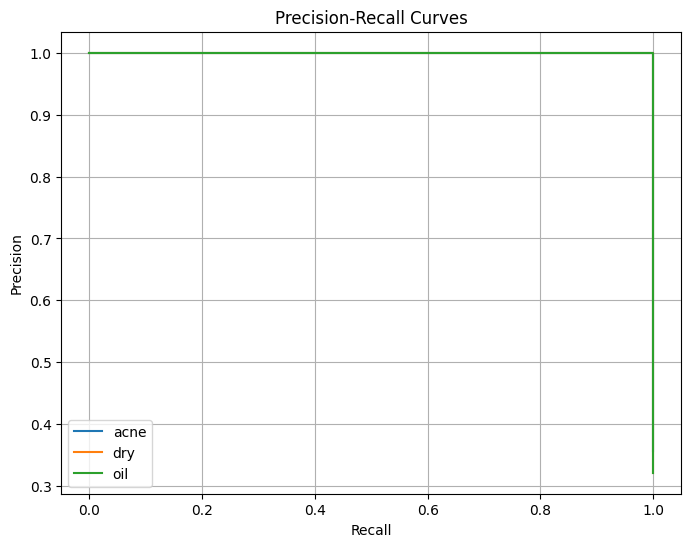

In [ ]:
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f"{class_name}")
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.show()

# --------------------------
# (3) Combined Accuracy & Loss Summary Grid
# --------------------------

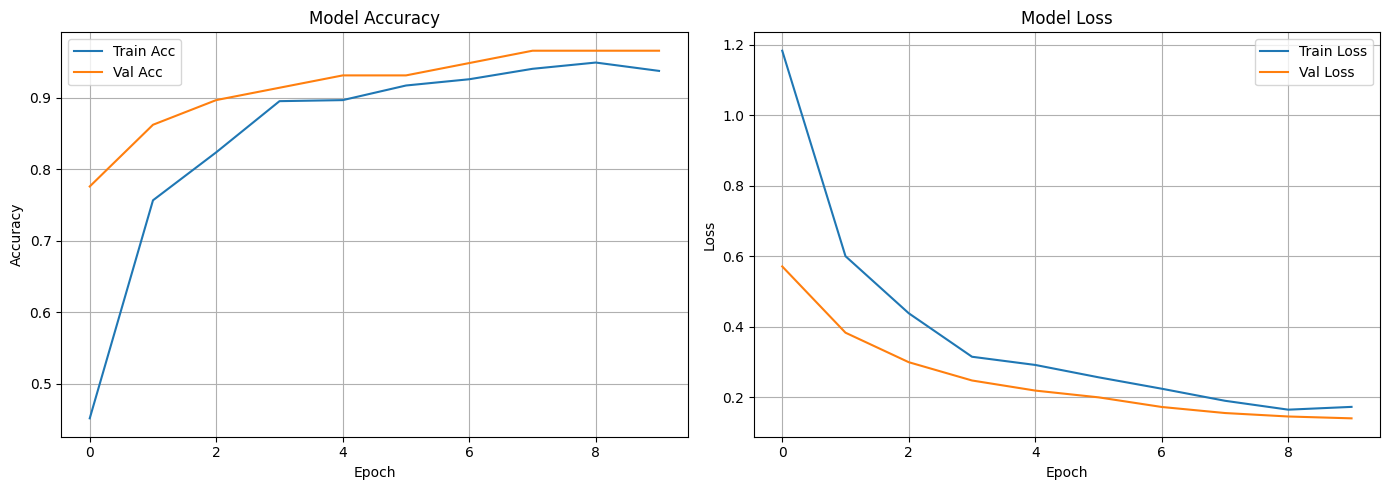

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid()

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# --------------------------
# (4) Class-wise Accuracy Bar Plot
# --------------------------

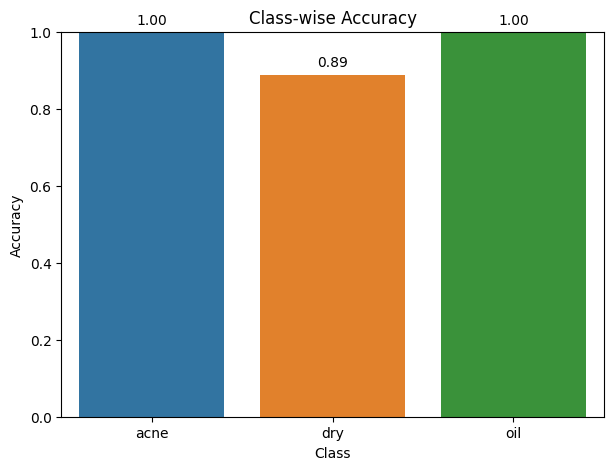

In [ ]:
from sklearn.metrics import accuracy_score

class_accuracies = []
for i, class_name in enumerate(class_names):
    idx = np.where(y_true == i)[0]
    class_acc = accuracy_score(y_true[idx], y_pred[idx])
    class_accuracies.append(class_acc)

plt.figure(figsize=(7, 5))
sns.barplot(x=class_names, y=class_accuracies)
plt.title("Class-wise Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, acc in enumerate(class_accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center')
plt.show()

# --------------------------
# (5) Normalized Confusion Matrix
# --------------------------

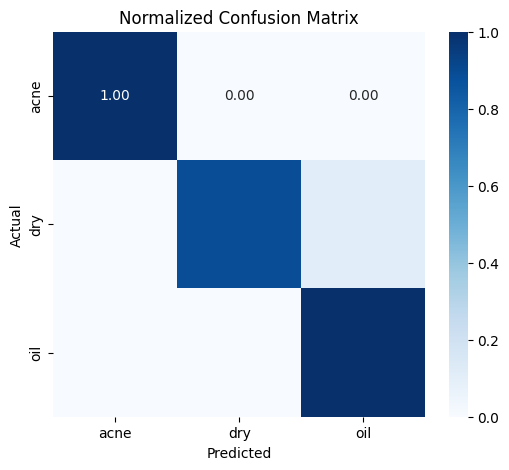

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
#import os
#save_dir = "Skin-Type-Recognition"
#os.makedirs(save_dir, exist_ok=True)
#model.save(os.path.join(save_dir, "vit_skin_model")) 
print("✅ Model saved successfully as TensorFlow SavedModel format (includes saved_model.pb) and variables/ directory.")


✅ Model saved successfully as TensorFlow SavedModel format (includes saved_model.pb) and variables/ directory.
